In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.pandas.set_option("display.max_columns",None)


In [185]:
df = pd.read_csv("D:\Dataset\CAR DETAILS FROM CAR DEKHO.csv")

In [186]:
df['brand'] = df['name'].apply(lambda x: x.split()[0])

In [187]:
df.drop(columns=['name'],inplace=True, axis=1)

In [188]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


In [189]:
features_with_na = [features for features in df.columns if df[features].isnull().sum()>=1]

for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

In [190]:
features_with_na

[]

In [191]:
# Handling Duplicates

In [192]:
df.duplicated().sum()

790

In [193]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O' ]
print('Num of Numerical Feature : ', len(num_features))

Num of Numerical Feature :  3


In [194]:
cat_features = [feature for feature in df.columns if df[feature].dtype =='O']
print('Num of Categorical Feature:', len(cat_features))

Num of Categorical Feature: 5


In [195]:
discrete_features = [feature for feature in num_features if len(df[feature].unique())<=25]

print('Num of Discrete feature:', len(discrete_features))

Num of Discrete feature: 0


In [196]:
continous_features = [feature for feature in num_features if feature not in discrete_features]
print('Num of Continous feature:', len(continous_features))

Num of Continous feature: 3


In [197]:
# Split X & Y


In [198]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


In [199]:
X = df.drop('brand',axis=1)
y = df['brand']

In [200]:
y.head()

0     Maruti
1     Maruti
2    Hyundai
3     Datsun
4      Honda
Name: brand, dtype: object

In [201]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the target variable 'y' before splitting
y = label_encoder.fit_transform(y)

In [202]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


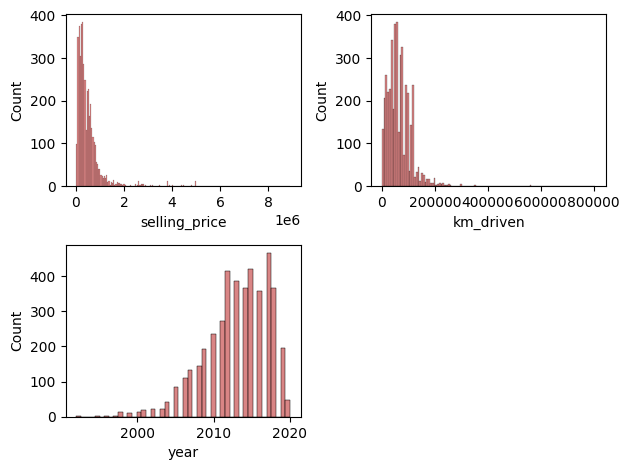

In [203]:
# Feature Transformation


plt.Figure(figsize=(12,6))
for i, col in enumerate(['selling_price','km_driven','year']):
    plt.subplot(2,2,i+1)
    sns.histplot(x=X[col],color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [204]:
# Checking for Skeness

In [205]:
X[continous_features].skew(axis=0,skipna=True)

year            -0.833240
selling_price    4.892021
km_driven        2.669057
dtype: float64

In [206]:
# Apply Power Transoformer to check if it can reduce the outliers

In [207]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
tranform_features = ['selling_price','km_driven']
X_copy = pt.fit_transform(X[tranform_features])

In [208]:
X_copy = pd.DataFrame(X_copy,columns=tranform_features)

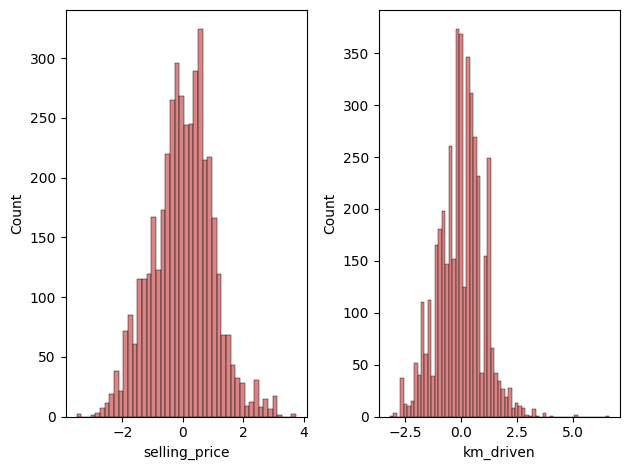

In [209]:
plt.Figure(figsize=(12,5))
for i, col in enumerate(tranform_features):
    plt.subplot(1,2,i+1)
    sns.histplot(x=X_copy[col],color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [210]:
# Checking for skewness

X_copy.skew(axis=0, skipna=True)

selling_price   -0.001403
km_driven        0.045700
dtype: float64

In [211]:
for feature in cat_features:
    print(feature,':',df[feature].nunique())

fuel : 5
seller_type : 3
transmission : 2
owner : 5
brand : 29


In [212]:
# Feature Encoding and Scaling Techniwues

In [213]:
num_features = list(X.select_dtypes(exclude='object').columns)

In [214]:
num_features

['year', 'selling_price', 'km_driven']

In [215]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


In [216]:
or_columns = ['fuel','seller_type','transmission']
oh_columns = ['owner']
transform_columns = ['selling_price','km_driven']


from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
ordinal_encoder = OrdinalEncoder()


transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer([
    ('OneHotEncoder', oh_transformer,oh_columns),
    ('Ordinal_Encoder', ordinal_encoder,or_columns),
    ('Transformer', transform_pipe,transform_columns),
    ('StandardScaler',numeric_transformer,num_features)
])

In [217]:
X = preprocessor.fit_transform(X)

In [218]:
X

array([[ 1.        ,  0.        ,  0.        , ..., -1.44507431,
        -0.76774602,  0.08113906],
       [ 1.        ,  0.        ,  0.        , ..., -1.44507431,
        -0.63809636, -0.3476891 ],
       [ 1.        ,  0.        ,  0.        , ..., -0.2587948 ,
         0.16573147,  0.7243813 ],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.97056251,
        -0.68131292,  0.35987736],
       [ 1.        ,  0.        ,  0.        , ...,  0.69022881,
         0.62382691,  0.50996722],
       [ 1.        ,  0.        ,  0.        , ...,  0.69022881,
        -0.48251678, -0.56210318]])

In [219]:
# Train Test Split

In [220]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((3472, 13), (868, 13))

In [221]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, \
            precision_score,recall_score,f1_score,roc_auc_score,roc_curve

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [222]:
def evaluate_clf(true, predicted):
    """
    Evaluate classification performance metrics for multiclass problems.

    Parameters:
        true (array-like): True labels
        predicted (array-like): Predicted labels

    Returns:
        Tuple: Accuracy, F1 score, Precision, Recall, ROC AUC score
    """
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
    import pandas as pd

    # Calculate metrics
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted, average='weighted')  # Weighted average for multiclass
    precision = precision_score(true, predicted, average='weighted')  # Weighted average for multiclass
    recall = recall_score(true, predicted, average='weighted')  # Weighted average for multiclass

    # Align dimensions for ROC AUC calculation
    try:
        true_dummies = pd.get_dummies(true)
        predicted_dummies = pd.get_dummies(predicted)
        
        # Align columns by reindexing
        predicted_dummies = predicted_dummies.reindex(columns=true_dummies.columns, fill_value=0)
        
        roc_auc = roc_auc_score(true_dummies, predicted_dummies, multi_class='ovr', average='weighted')
    except ValueError:
        roc_auc = None  # Assign None if ROC AUC is not applicable

    return acc, f1, precision, recall, roc_auc


In [223]:
models = {
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Logistic Regression': LogisticRegression(),
    'K-Neighbors Classifiers': KNeighborsClassifier(),
    'XGBClassifier': XGBClassifier(),
    'CatBoosting Classifier': CatBoostClassifier(verbose=False),
    'Support Vector Classifier': SVC(),
    'AdaBoost Classifier': AdaBoostClassifier()

}

In [224]:
from sklearn.model_selection import train_test_split
import pandas as pd

def evaluate_models(X, y, models):
    """
    This function takes X, y, and a dictionary of models as input.
    It splits the data into train and test sets, iterates through the given models,
    and evaluates the metrics for each model.
    
    Parameters:
        X (DataFrame): Features dataset
        y (Series or array): Target dataset
        models (dict): Dictionary of model names as keys and model instances as values
    
    Returns:
        pd.DataFrame: DataFrame containing model names and their test accuracies
    """

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Lists to store results
    models_list = []
    accuracy_list = []
    auc_list = []

    # Iterate through models
    for model_name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Evaluate training set performance
        model_train_accuracy, model_train_f1, model_train_precision, \
        model_train_recall, model_train_rocauc_score = evaluate_clf(y_train, y_train_pred)

        # Evaluate test set performance
        model_test_accuracy, model_test_f1, model_test_precision, \
        model_test_recall, model_test_rocauc_score = evaluate_clf(y_test, y_test_pred)

        # Print model name
        print(f'Model: {model_name}')
        models_list.append(model_name)

        # Print training set performance
        print('Model performance for training set')
        print('-- Accuracy: {:.4f}'.format(model_train_accuracy))
        print('-- F1 score: {:.4f}'.format(model_train_f1))
        print('-- Precision: {:.4f}'.format(model_train_precision))
        print('-- Recall: {:.4f}'.format(model_train_recall))
        print('-- Roc AUC Score: {:.4f}'.format(model_train_rocauc_score))

        print('------------------------------------------------------')

        # Print test set performance
        print('Model performance for test set')
        print('-- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('-- F1 score: {:.4f}'.format(model_test_f1))
        print('-- Precision: {:.4f}'.format(model_test_precision))
        print('-- Recall: {:.4f}'.format(model_test_recall))
        print('-- Roc AUC Score: {:.4f}'.format(model_test_rocauc_score))
        auc_list.append(model_test_rocauc_score)

        print('=' * 35)
        print('\n')

    # Create a report DataFrame
    report = pd.DataFrame({
        'Model Name': models_list,
        'Accuracy': accuracy_list,
        'AUC': auc_list
    }).sort_values(by='Accuracy', ascending=False)

    return report


In [225]:
# Model Training

In [226]:
base_model_report = evaluate_models(X=X,y=y,models=models)

Model: Random Forest
Model performance for training set
-- Accuracy: 0.9888
-- F1 score: 0.9888
-- Precision: 0.9888
-- Recall: 0.9888
-- Roc AUC Score: 0.9931
------------------------------------------------------
Model performance for test set
-- Accuracy: 0.4954
-- F1 score: 0.4857
-- Precision: 0.4931
-- Recall: 0.4954
-- Roc AUC Score: 0.6931


Model: Decision Tree
Model performance for training set
-- Accuracy: 0.9888
-- F1 score: 0.9888
-- Precision: 0.9889
-- Recall: 0.9888
-- Roc AUC Score: 0.9934
------------------------------------------------------
Model performance for test set
-- Accuracy: 0.4366
-- F1 score: 0.4384
-- Precision: 0.4499
-- Recall: 0.4366
-- Roc AUC Score: 0.6703


Model: Gradient Boosting
Model performance for training set
-- Accuracy: 0.6377
-- F1 score: 0.6301
-- Precision: 0.6741
-- Recall: 0.6377
-- Roc AUC Score: 0.7653
------------------------------------------------------
Model performance for test set
-- Accuracy: 0.4551
-- F1 score: 0.4297
-- Pre

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27], got [ 0  1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28]